# Aula 5 – Versão visual e detalhada

**Curso:** Machine Learning Aplicada à Indústria  
**Versão:** Aluno

## Objetivo
Nesta aula, você irá observar e registrar:
- preparação dos dados de entrada (`X`) e da variável-alvo (`y`);
- padronização da base;
- divisão em treino e validação;
- criação do modelo;
- treino e validação;
- leitura de métricas;
- interpretação dos gráficos.


## 1. Importação das bibliotecas

Execute o bloco abaixo e observe quais bibliotecas estão sendo usadas.

Durante nossa aula, vamos utilizar algumas bibliotecas. Cada uma terá uma função específica no nosso projeto. Vamos conhecê-las uma por uma conforme avançarmos nas etapas.


In [71]:
# 1. Pandas → carregar e manipular os dados.
# 2. NumPy → trabalhar com cálculos numéricos.
# 3. Matplotlib → criar gráficos.
# 4. train_test_split → separar os dados em treino e teste.
# 5. ColumnTransformer → aplicar tratamentos diferentes às colunas.
# 6. Pipeline → organizar as etapas do processamento.
# 7. OneHotEncoder → transformar categorias em números.
# 8. StandardScaler → padronizar os dados numéricos.
# 9. LabelEncoder → transformar categorias em números.
# 10. SimpleImputer → tratar valores ausentes.
# 11. DecisionTreeClassifier → criar o modelo de Árvore de Decisão.
# 12. KMeans → encontrar grupos de dados semelhantes.
# 13. LabelSpreading → classificação semissupervisionda.
# 14. Métricas → avaliar o desempenho dos modelos.
# 14.1 accuracy_score → mede a quantidade de acertos do modelo.
# 14.2 classification_report → apresenta várias métricas de desempenho.
# 14.3 confusion_matrix → mostra os acertos e erros de cada classe.
# 14.4 silhouette_score → avalia a qualidade dos grupos encontrados.

# 1 e 2. Manipulação de Dados e Computação Numérica
import pandas as pd
import numpy as np

# 3. Visualização de Dados
import matplotlib.pyplot as plt

# 4. Divisão dos Dados (Treino e Teste)
from sklearn.model_selection import train_test_split

# 5, 6, 7, 8, 9, 10. Pré-processamento e Transformação
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# 11, 12, 13. Algoritmos de Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelSpreading

# 14. Métricas de Avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


### Registro do aluno
Explique com suas palavras:
- para que serve o Scikit-learn;
- por que ele é importante para Machine Learning.


In [72]:
df = pd.read_csv("/content/base_aula5_tipos_aprendizado_industria.csv")
print("Dimensões da base:", df.shape)
df.head()

Dimensões da base: (240, 19)


,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba,status_instrumentacao,acao_ideal_controle
0,Linha_C,Manhã,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257,Normal,Reduzir_Abertura
1,Linha_B,Noite,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892,Normal,Manter_Ajuste
2,Linha_C,Manhã,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382,Normal,Manter_Ajuste
3,Linha_B,Noite,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543,Normal,Aumentar_Abertura
4,Linha_A,Tarde,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401,Falha,Aumentar_Abertura


### Estatisticas do dataset

In [73]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
linha_producao,240,3,Linha_A,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turno,240,3,Noite,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto_quimico,240,3,Acido,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_valvula,240,3,Borboleta,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_sensor,240,3,OK,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vazao_setpoint_l_min,240.0,NaN,NaN,NaN,100.489917,11.62172,56.22,93.9975,100.825,107.5875,133.71
vazao_real_l_min,240.0,NaN,NaN,NaN,100.250458,13.371414,54.96,92.4175,101.025,108.89,135.97
erro_vazao_pct,240.0,NaN,NaN,NaN,-0.269917,6.378737,-23.84,-4.3875,-0.14,3.9125,14.56
pressao_linha_bar,240.0,NaN,NaN,NaN,5.729875,0.948048,3.14,5.11,5.78,6.3125,8.42
desvio_pressao_pct,240.0,NaN,NaN,NaN,-1.209208,16.345756,-45.86,-11.8925,-0.34,8.835,45.17


###Selecionar a variavel<br>

>status_instrumentacao

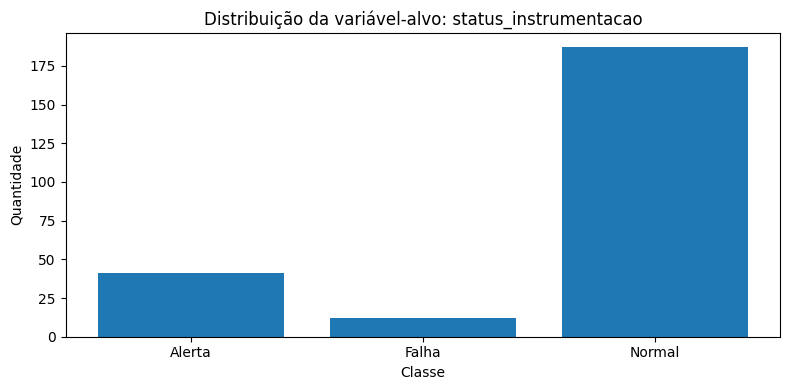

In [74]:
variave_alvo = 'status_instrumentacao'
classe_counts = df[variave_alvo].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(classe_counts.index, classe_counts.values)
plt.title(f"Distribuição da variável-alvo: {variave_alvo}")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

## 2. Preparação dos dados

Complete a execução do bloco abaixo e observe a separação entre:
- variáveis preditoras (`X`);
- variável-alvo (`y`).

> Para este exercicio iremos resmover do conjunto de X
`"status_instrumentacao" & "acao_ideal_controle"`

### Pergunta de negócio

>"Podemos prever antecipadamente o status da instrumentação de um processo industrial para identificar possíveis situações de atenção e apoiar a tomada de decisão operacional?"<br>
Sim. Podemos construir um modelo de classificação supervisionada para estimar o `status_instrumentacao` (Normal, Alerta ou Falha) a partir das variáveis operacionais disponíveis. O objetivo é identificar antecipadamente condições que demandem atenção e, dessa forma, apoiar a tomada de decisões operacionais.


In [75]:
# Variáveis preditoras (X): tudo o que o modelo usará para aprender
X = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"])

# Variável-alvo (y): aquilo que desejamos prever
y = df["status_instrumentacao"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nPrimeiras linhas de X:")
display(X.head())
print("\nPrimeiras linhas de y:")
display(y.head())

Formato de X: (240, 17)
Formato de y: (240,)

Primeiras linhas de X:


,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba
0,Linha_C,Manhã,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257
1,Linha_B,Noite,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892
2,Linha_C,Manhã,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382
3,Linha_B,Noite,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543
4,Linha_A,Tarde,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401



Primeiras linhas de y:


,status_instrumentacao
0,Normal
1,Normal
2,Normal
3,Normal
4,Falha


### Reflexão

**Qual coluna foi escolhida como variável-alvo?**

A coluna `status_instrumentacao`, que classifica a situação da instrumentação em três categorias: Normal, Alerta ou Falha. É isso que queremos que o modelo aprenda a prever a partir das demais medições do processo.

**Por que ela não deve permanecer dentro de `X`?**

Se a resposta correta estiver entre as variáveis preditoras, o modelo não precisa aprender nenhuma relação entre as medições (vibração, energia, tempo de resposta etc.) e o status. Ele apenas copia a coluna que já contém o gabarito. Isso traz três problemas:

- **Desempenho artificialmente perfeito:** a acurácia seria próxima de 100%, mas sem nenhum aprendizado real.
- **Modelo inútil na prática:** em uso real, o status ainda não é conhecido no momento da previsão (é justamente o que queremos descobrir). Um modelo que depende dele não consegue funcionar.
- **Avaliação enganosa:** o resultado não diz nada sobre a capacidade do modelo de generalizar para dados novos.

In [76]:
colunas_numericas = X.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)
print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['vazao_setpoint_l_min', 'vazao_real_l_min', 'erro_vazao_pct', 'pressao_linha_bar', 'desvio_pressao_pct', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'tempo_resposta_seg', 'horas_operacao_bomba']

Colunas categóricas:
['linha_producao', 'turno', 'produto_quimico', 'tipo_valvula', 'status_sensor']


## 3. Padronização e preparação da base

Observe como o código trata:
- colunas numéricas;
- colunas categóricas.


In [77]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas)
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


### Reflexão
- Por que as colunas numéricas são padronizadas?<br>
As colunas numéricas são padronizadas para colocar as variáveis em escalas comparáveis, evitando que variáveis com valores numericamente maiores tenham influência desproporcional no modelo. O StandardScaler transforma os valores para uma distribuição com média próxima de 0 e desvio padrão próximo de 1.
- Por que as colunas categóricas precisam de codificação?<br>
Porque os modelos de Machine Learning trabalham com representações numéricas. Variáveis categóricas como turno, produto ou status_sensor contêm textos e precisam ser transformadas em números.


## 4. Divisão da base em treino e validação

Execute o bloco e compare os tamanhos dos conjuntos.


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Formato/Dimensoes de X_train:",X_train.shape )
print("Formato/Dimensoes de X_test:", X_test.shape)
print("Formato/Dimensoes de y_train:", y_train.shape)
print("Formato/Dimensoes de y_test:", y_test.shape)

Formato/Dimensoes de X_train: (180, 17)
Formato/Dimensoes de X_test: (60, 17)
Formato/Dimensoes de y_train: (60,)
Formato/Dimensoes de y_test: (60,)


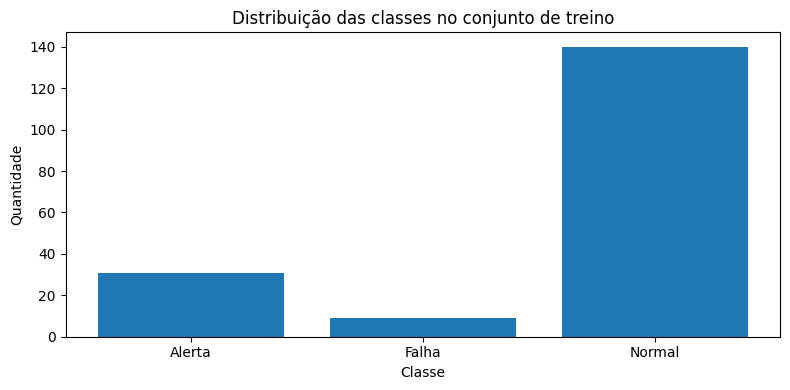

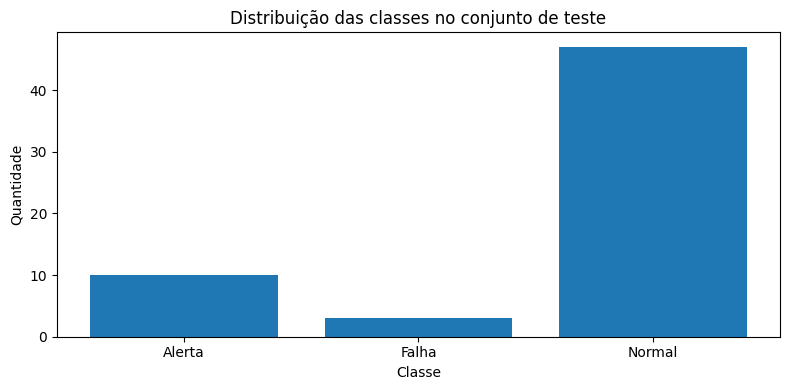

In [79]:
train_counts = y_train.value_counts().sort_index()
val_counts = y_test.value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(val_counts.index, val_counts.values)
plt.title("Distribuição das classes no conjunto de teste")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- Qual é a função do conjunto de treino?<br>
O conjunto de treino é utilizado para que o modelo aprenda os padrões existentes nos dados. É nele que o algoritmo identifica relações entre as variáveis de entrada e a variável-alvo, status_instrumentacao.
- Qual é a função do conjunto de teste?<br>
O conjunto de teste é utilizado para verificar se o modelo consegue generalizar o que aprendeu para dados que não foram utilizados durante o treinamento.

- O que significa preservar a proporção das classes?
Significa fazer a divisão entre treino e teste mantendo, aproximadamente, a mesma distribuição das categorias da variável-alvo nos dois conjuntos.


## 5. Criação do modelo supervisionado

In [80]:
modelo_supervisionado = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", DecisionTreeClassifier(max_depth=4, random_state=42))
])

modelo_supervisionado

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vazao_setpoint_l_min',
                                                   'vazao_real_l_min',
                                                   'erro_vazao_pct',
                                                   'pressao_linha_bar',
                                                   'desvio_pressao_pct',
                                                   'temperatura_produto_c',
                                                   'abertura_valvula_pct',
                                                   'vibracao_bomba_mm_s',
                                                   'ph_produto',
                                                   'consumo_energia_kwh',
                                                   'tempo_resposta_seg',
                                                   'horas_operacao_bomba']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['linha_producao', 'turno',
                                                   'produto_quimico',
                                                   'tipo_valvula',
                                                   'status_sensor'])])),
                ('modelo',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

## 6. Treino, validação e métricas

In [81]:
modelo_supervisionado.fit(X_train, y_train)
pred_supervisionado = modelo_supervisionado.predict(X_test)

acc = accuracy_score(y_test, pred_supervisionado)

print("Acurácia na teste:", round(acc, 4))
print("\nRelatório de classificação:")
print(classification_report(y_test, pred_supervisionado))

Acurácia na teste: 0.7667

Relatório de classificação:
              precision    recall  f1-score   support

      Alerta       0.17      0.10      0.12        10
       Falha       0.00      0.00      0.00         3
      Normal       0.85      0.96      0.90        47

    accuracy                           0.77        60
   macro avg       0.34      0.35      0.34        60
weighted avg       0.69      0.77      0.73        60



###Anatomia da metricas auxiliares do modelo preditivo

In [82]:
relatorio = classification_report(
    y_test,
    pred_supervisionado,
    output_dict=True
)

print("ACURÁCIA")
print(f"Valor: {acc:.2%}")
print("Indica o percentual geral de previsões que o modelo acertou.")


print("\n===== CLASSE ALERTA =====")

print(f"Precision: {relatorio['Alerta']['precision']:.2f}")
print("Indica, entre todas as previsões de Alerta, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Alerta']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Alerta, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Alerta']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall. Quanto maior, melhor o desempenho.")

print(f"Support: {relatorio['Alerta']['support']}")
print("Indica a quantidade de casos reais da classe Alerta na validação.")


print("\n===== CLASSE FALHA =====")

print(f"Precision: {relatorio['Falha']['precision']:.2f}")
print("Indica, entre todas as previsões de Falha, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Falha']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Falha, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Falha']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall.")

print(f"Support: {relatorio['Falha']['support']}")
print("Indica a quantidade de casos reais da classe Falha na validação.")


print("\n===== CLASSE NORMAL =====")

print(f"Precision: {relatorio['Normal']['precision']:.2f}")
print("Indica, entre todas as previsões de Normal, quantas estavam realmente corretas.")

print(f"Recall: {relatorio['Normal']['recall']:.2f}")
print("Indica, entre todos os casos que realmente eram Normal, quantos o modelo conseguiu identificar.")

print(f"F1-score: {relatorio['Normal']['f1-score']:.2f}")
print("Representa o equilíbrio entre Precision e Recall.")

print(f"Support: {relatorio['Normal']['support']}")
print("Indica a quantidade de casos reais da classe Normal na validação.")

print("\n===== ACCURACY =====")
print(f"Accuracy: {acc:.2f}")
print("Representa o percentual geral de previsões que o modelo acertou.")
print(f"Quantidade de casos avaliados: {len(y_test)}")
print("Indica quantos registros foram utilizados para calcular a acurácia.")


print("\n===== MACRO AVG =====")
print(f"Precision: {relatorio['macro avg']['precision']:.2f}")
print("É a média da Precision das classes Alerta, Falha e Normal, dando o mesmo peso para cada classe.")

print(f"Recall: {relatorio['macro avg']['recall']:.2f}")
print("É a média do Recall das classes, considerando todas as classes com o mesmo peso.")

print(f"F1-score: {relatorio['macro avg']['f1-score']:.2f}")
print("É a média dos F1-scores das três classes, dando o mesmo peso para cada classe.")

print(f"Support: {relatorio['macro avg']['support']}")
print("Representa o total de registros utilizados na avaliação.")


print("\n===== WEIGHTED AVG =====")
print(f"Precision: {relatorio['weighted avg']['precision']:.2f}")
print("É a média da Precision considerando a quantidade de exemplos de cada classe.")

print(f"Recall: {relatorio['weighted avg']['recall']:.2f}")
print("É a média do Recall considerando a quantidade de exemplos de cada classe.")

print(f"F1-score: {relatorio['weighted avg']['f1-score']:.2f}")
print("É a média do F1-score considerando a quantidade de exemplos de cada classe.")

print(f"Support: {relatorio['weighted avg']['support']}")
print("Representa o total de registros utilizados na avaliação.")

ACURÁCIA
Valor: 76.67%
Indica o percentual geral de previsões que o modelo acertou.

===== CLASSE ALERTA =====
Precision: 0.17
Indica, entre todas as previsões de Alerta, quantas estavam realmente corretas.
Recall: 0.10
Indica, entre todos os casos que realmente eram Alerta, quantos o modelo conseguiu identificar.
F1-score: 0.12
Representa o equilíbrio entre Precision e Recall. Quanto maior, melhor o desempenho.
Support: 10.0
Indica a quantidade de casos reais da classe Alerta na validação.

===== CLASSE FALHA =====
Precision: 0.00
Indica, entre todas as previsões de Falha, quantas estavam realmente corretas.
Recall: 0.00
Indica, entre todos os casos que realmente eram Falha, quantos o modelo conseguiu identificar.
F1-score: 0.00
Representa o equilíbrio entre Precision e Recall.
Support: 3.0
Indica a quantidade de casos reais da classe Falha na validação.

===== CLASSE NORMAL =====
Precision: 0.85
Indica, entre todas as previsões de Normal, quantas estavam realmente corretas.
Recall: 0

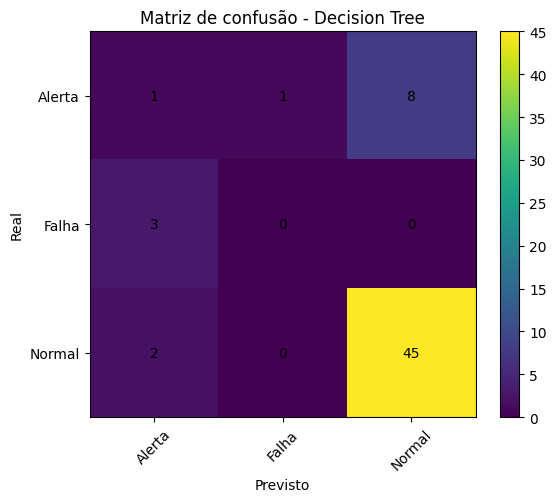

In [83]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred_supervisionado,labels=labels)




plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de confusão - Decision Tree")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Explicação da Matriz de Confusão

In [84]:
print("\n===== INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO =====")

print(f"Alerta: havia {cm[0].sum()} casos reais.")
print(f"O modelo acertou {cm[0,0]} e classificou {cm[0,1]} como Falha e {cm[0,2]} como Normal. Errou 9")

print(f"\nFalha: havia {cm[1].sum()} casos reais.")
print(f"O modelo acertou {cm[1,1]} e classificou {cm[1,0]} como Alerta e {cm[1,2]} como Normal. Errou tudo")

print(f"\nNormal: havia {cm[2].sum()} casos reais.")
print(f"O modelo acertou {cm[2,2]} e classificou {cm[2,0]} como Alerta e {cm[2,1]} como Falha.")

print("\nConclusão:")
print(f"O modelo acertou {cm[0,0] + cm[1,1] + cm[2,2]} de {cm.sum()} casos.")
print("O modelo apresenta melhor desempenho na identificação da classe Normal.")


===== INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO =====
Alerta: havia 10 casos reais.
O modelo acertou 1 e classificou 1 como Falha e 8 como Normal. Errou 9

Falha: havia 3 casos reais.
O modelo acertou 0 e classificou 3 como Alerta e 0 como Normal. Errou tudo

Normal: havia 47 casos reais.
O modelo acertou 45 e classificou 2 como Alerta e 0 como Falha.

Conclusão:
O modelo acertou 46 de 60 casos.
O modelo apresenta melhor desempenho na identificação da classe Normal.


## Análise dos Resultados do Modelo

### Qual foi a acurácia obtida?

A acurácia foi de **76,67%**.

### Em quais classes o modelo parece ter acertado mais?

A classe em que o modelo teve melhor desempenho foi **Normal**.

### Onde houve confusão?

A principal confusão aconteceu justamente nas classes que são mais importantes para o nosso problema de negócio: **Alerta** e **Falha**.

## 7. Demonstração não supervisionada

**Podemos identificar perfis distintos de operação no processo industrial, agrupando equipamentos ou situações com características semelhantes para apoiar decisões de monitoramento e controle?**

ou

**Quais são os diferentes perfis de operação existentes no processo industrial?**

---

Com base nas variáveis operacionais disponíveis, podemos identificar diferentes perfis de operação no processo industrial. De forma geral, os dados sugerem a existência de:

- **Perfil estável:** caracterizado por menores níveis de vibração e consumo de energia;
- **Perfil intermediário:** com sinais de alteração em algumas variáveis operacionais;
- **Perfil crítico:** associado a maiores níveis de vibração, consumo de energia e possíveis desvios nas condições do processo.

O agrupamento por técnicas de aprendizado não supervisionado, como o **K-Means**, pode ser utilizado para identificar esses grupos de forma automática, permitindo caracterizar os diferentes perfis de operação e apoiar estratégias de monitoramento e controle do processo.

In [85]:
X_cluster = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"]).copy()

colunas_numericas_cluster = X_cluster.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas_cluster = X_cluster.select_dtypes(include=['object']).columns.tolist()

preprocessador_cluster = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_semi),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_semi)
    ]
)

X_cluster_transformado = preprocessador_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_transformado)

sil = silhouette_score(X_cluster_transformado, clusters)

print("Silhouette Score:", round(sil, 4))
print(pd.Series(clusters).value_counts().sort_index())

Silhouette Score: 0.0761
0    107
1     71
2     62
Name: count, dtype: int64


### Interpretação metodológica do clustering

O K-Means foi configurado com `k = 3`, portanto os três grupos foram **solicitados pelo experimento**, e não descobertos automaticamente.

O `Silhouette Score` obtido foi baixo (`0,0761`), indicando pouca separação entre os clusters. Assim, **não é adequado afirmar que os dados revelam três perfis operacionais claramente distintos**.

Uma conclusão mais rigorosa é:

> O K-Means conseguiu particionar os dados em três grupos, mas o baixo Silhouette Score indica que esses grupos apresentam forte sobreposição. Portanto, o experimento não fornece evidência forte de três perfis naturalmente bem separados.

Para uma análise mais completa, seria interessante comparar diferentes valores de `k` e observar como o Silhouette Score varia.

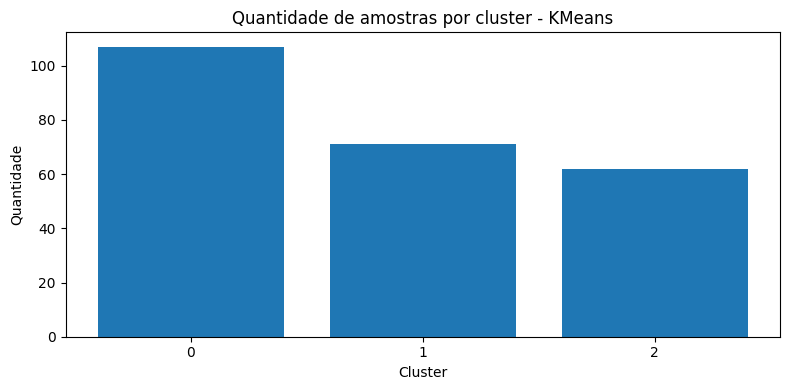

In [86]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Quantidade de amostras por cluster - KMeans")
plt.xlabel("Cluster")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

| Silhouette       | Interpretação                      |
| ---------------- | ---------------------------------- |
| próximo de **1** | 🟢 Grupos muito bem separados      |
| próximo de **0** | 🟡 Grupos muito semelhantes        |
| negativo         | 🔴 Possível agrupamento inadequado |

## Reflexão

### O que o K-Means está tentando encontrar?

O K-Means busca **grupos de observações com características semelhantes**. No contexto industrial, o objetivo é identificar diferentes **perfis de operação** a partir das variáveis disponíveis, agrupando situações que apresentam comportamentos parecidos.

### Por que ele não precisa da variável-alvo?

Porque o K-Means é um algoritmo de **aprendizado não supervisionado**. Ele não recebe uma variável-alvo para aprender a prever; em vez disso, utiliza as próprias características das observações para descobrir automaticamente os grupos existentes nos dados.

Assim, a variável `status_instrumentacao` não é necessária para realizar o agrupamento.


## 8. Demonstração semi-supervisionada

## Pergunta de negócio

> Podemos identificar o status da instrumentação em registros que não foram classificados, utilizando como referência os padrões encontrados em registros já classificados?
Sim. Podemos utilizar uma abordagem de **aprendizado semissupervisionado** quando temos uma parte dos registros com o `status_instrumentacao` conhecido e outra parte sem classificação. Os registros classificados servem como referência para identificar padrões nos dados e auxiliar na atribuição do status aos registros que ainda não foram classificados.

Essa abordagem pode ser útil em situações nas quais a classificação manual de todos os registros seria trabalhosa ou custosa, permitindo aproveitar **tanto os dados classificados quanto os não classificados**.

In [87]:
X_semi = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"])
y_semi = df["status_instrumentacao"].copy()

colunas_numericas_semi = X_semi.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas_semi = X_semi.select_dtypes(include=['object']).columns.tolist()

preprocessador_semi = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_semi),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_semi)
    ]
)

# 1. Ajusta e transforma os dados de entrada
X_semi_transformado = preprocessador_semi.fit_transform(X_semi)

# 2. Codifica os rótulos em formato numérico
label_encoder = LabelEncoder()
y_codificado = label_encoder.fit_transform(y_semi)

rng = np.random.default_rng(42)

# 3. Faz uma cópia dos rótulos para manipular
y_parcial = y_codificado.copy()
indices_sem_rotulo = rng.choice(len(y_parcial), size=int(len(y_parcial) * 0.6), replace=False)

# Substitui 60% dos rótulos por -1 (sem rótulo)
y_parcial[indices_sem_rotulo] = -1

# 4. Treina o modelo LabelSpreading
modelo_semi = LabelSpreading(kernel="knn", n_neighbors=7)
modelo_semi.fit(X_semi_transformado, y_parcial)

# Obtém as predições para todo o conjunto de dados
rotulos_previstos = modelo_semi.transduction_

# Máscaras booleanas de seleção
mascara_rotulada = y_parcial != -1
mascara_nao_rotulada = y_parcial == -1

# 5 e 6. Calcula a acurácia nos dois subconjuntos
acc_rot = accuracy_score(y_codificado[mascara_rotulada], rotulos_previstos[mascara_rotulada])
acc_nao_rot = accuracy_score(y_codificado[mascara_nao_rotulada], rotulos_previstos[mascara_nao_rotulada])

print("Acurácia nas amostras rotuladas:", round(acc_rot, 4))
print("Acurácia nas amostras sem rótulo para o algoritmo:", round(acc_nao_rot, 4))

Acurácia nas amostras rotuladas: 1.0
Acurácia nas amostras sem rótulo para o algoritmo: 0.7847


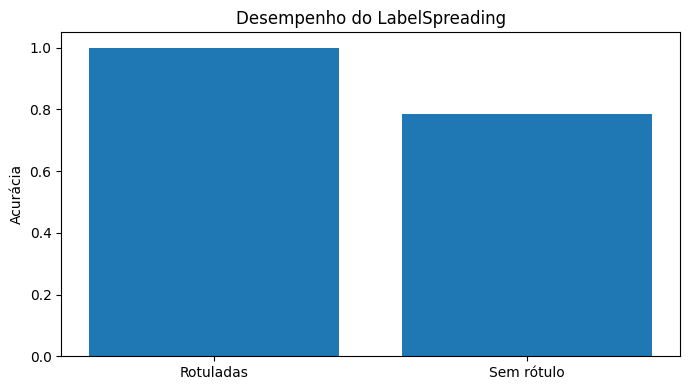

In [88]:
plt.figure(figsize=(7,4))
plt.bar(["Rotuladas", "Sem rótulo"], [acc_rot, acc_nao_rot])
plt.title("Desempenho do LabelSpreading")
plt.ylabel("Acurácia")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Resumindo cada etapa:

1. **Identifica os tipos de dados**

```python
colunas_numericas_semi
colunas_categoricas_semi
```

→ Separa as colunas **numéricas** das **categóricas**.

2. **Prepara os dados**

```python
preprocessador_semi
```

→ Corrige valores vazios, padroniza números e transforma categorias em números.

3. **Transforma os dados**

```python
X_semi_transformado
```

→ Deixa os dados prontos para o algoritmo.

4. **Transforma os rótulos em números**

```python
y_codificado
```

→ Por exemplo: `Normal = 0`, `Alerta = 1`, `Falha = 2`.

5. **Remove 60% dos rótulos**

```python
y_parcial[indices_sem_rotulo] = -1
```

→ Simula uma situação onde **60% dos dados não possuem classificação conhecida** aplica o valor -1 para 60% dos valores do array y_parcial. É uma das partes mais importantes da etapa do aprendizado semi-supervisionado!

6. **Aplica o LabelSpreading**

```python
LabelSpreading(kernel="knn", n_neighbors=7)
```

→ Usa os **7 vizinhos mais próximos** para tentar descobrir os rótulos dos dados que ficaram sem classificação.

7. **Compara os resultados**

```python
acc_rot
acc_nao_rot
```

→ Calcula:
* **Acurácia dos dados que tinham rótulo**
* **Acurácia dos dados que estavam sem rótulo e foram previstos pelo algoritmo**



### **Conclusão**

> **O código pega os dados, esconde os rótulos de 60% deles e testa se o LabelSpreading consegue descobrir corretamente esses rótulos usando a semelhança entre os registros.**


### Reflexão

#### O que muda quando parte dos rótulos é escondida?

Quando parte dos rótulos é escondida, o modelo passa a trabalhar com uma combinação de **dados rotulados e não rotulados**. Os registros que continuam classificados servem como referência para identificar os padrões existentes, enquanto os registros sem classificação podem ser utilizados para complementar essa aprendizagem.

#### Qual é a vantagem desse tipo de abordagem?

A principal vantagem é permitir o **aproveitamento de uma grande quantidade de dados que não foram classificados manualmente**. Isso pode reduzir o esforço e o custo da rotulagem, aproveitando os.


## 9. Demonstração da lógica do reforço

### Pergunta de negócio

> Qual estratégia de controle pode tomar melhores decisões para corrigir o erro de vazão e maximizar o resultado operacional do processo?

 Essa pergunta pode ser abordada por meio do **aprendizado por reforço**. Nesse tipo de aprendizado, um **agente** interage com o processo industrial, observa o estado atual, escolhe uma **ação de controle** e recebe uma **recompensa** de acordo com o resultado obtido.

No contexto do processo, o agente pode aprender, por exemplo, quando **aumentar ou diminuir a abertura da válvula** para reduzir o erro de vazão. Ao longo das interações, ele busca aprender uma estratégia que **maximize as recompensas** e, consequentemente, melhore o desempenho operacional do processo.

In [89]:
# 1. Ações possíveis identificadas pela função política_heuristica
acoes_possiveis = ["Aumentar_Abertura", "Reduzir_Abertura", "Manter_Ajuste"]

# 2. Seleciona as colunas de erro e a ação real ideal do DataFrame original
df_rl = df[["erro_vazao_pct", "acao_ideal_controle"]].copy()

rng = np.random.default_rng(42)
acoes_aleatorias = rng.choice(acoes_possiveis, size=len(df_rl))

# 3. Define a ação do agente aleatório e calcula sua recompensa (+1 se acertar, -1 se errar)
df_rl["acao_agente_aleatorio"] = acoes_aleatorias
df_rl["recompensa_aleatoria"] = np.where(
    df_rl["acao_agente_aleatorio"] == df_rl["acao_ideal_controle"], 1, -1
)

# Definição da regra/política heurística
def politica_heuristica(erro):
    if erro < -3:
        return "Aumentar_Abertura"
    elif erro > 3:
        return "Reduzir_Abertura"
    else:
        return "Manter_Ajuste"

# 4. Aplica a política heurística na coluna de erro e calcula sua recompensa
df_rl["acao_heuristica"] = df_rl["erro_vazao_pct"].apply(politica_heuristica)
df_rl["recompensa_heuristica"] = np.where(
    df_rl["acao_heuristica"] == df_rl["acao_ideal_controle"], 1, -1
)

# 5. Soma total das recompensas de cada estratégia
recompensa_total_agente = df_rl["recompensa_aleatoria"].sum()
recompensa_total_heuristica = df_rl["recompensa_heuristica"].sum()

# 6. Exibe os resultados
print("Recompensa total do agente aleatório:", recompensa_total_agente)
print("Recompensa total da heurística:", recompensa_total_heuristica)

Recompensa total do agente aleatório: -66
Recompensa total da heurística: 240


### Observação importante sobre o experimento de aprendizado por reforço

Esta etapa é uma **demonstração conceitual dos elementos do aprendizado por reforço**, e não a implementação de um algoritmo de RL que aprende uma política.

A política heurística foi definida previamente por regras:

- erro muito negativo → aumentar abertura;
- erro muito positivo → reduzir abertura;
- erro próximo de zero → manter ajuste.

Portanto, a política **não foi aprendida pelo agente**. A recompensa serve para comparar o comportamento de uma política aleatória com uma regra previamente definida.

Em um algoritmo de aprendizado por reforço propriamente dito, o agente atualizaria sua política com base nas experiências de estado → ação → recompensa → próximo estado.

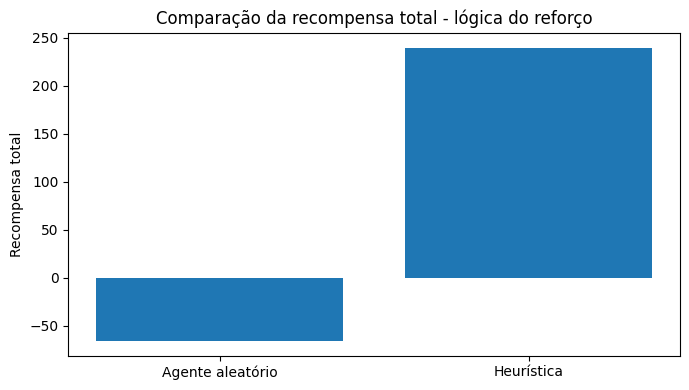

In [90]:
plt.figure(figsize=(7,4))
plt.bar(["Agente aleatório", "Heurística"], [recompensa_total_agente, recompensa_total_heuristica])
plt.title("Comparação da recompensa total - lógica do reforço")
plt.ylabel("Recompensa total")
plt.tight_layout()
plt.show()

### Reflexão

#### O que representa o estado?

O **estado** representa a **situação atual do processo industrial**. Ele pode ser descrito por variáveis como erro de vazão, pressão, temperatura, abertura da válvula e outras informações que caracterizam as condições do processo naquele momento.

#### O que representa a ação?

A **ação** representa a **decisão tomada pelo agente** para interferir no processo. Nesse contexto, pode ser, por exemplo, aumentar, diminuir ou manter a abertura da válvula com o objetivo de corrigir o erro de vazão.

#### O que representa a recompensa?

A **recompensa** representa o **resultado obtido após a ação**. Uma ação que reduz o erro de vazão e melhora o desempenho do processo pode receber uma recompensa positiva, enquanto uma ação que prejudica o processo pode receber uma recompensa menor ou negativa.

#### Por que essa lógica é diferente dos outros tipos de aprendizado?

A lógica é diferente porque, no aprendizado por reforço, o modelo não apenas aprende a identificar ou prever padrões. Ele aprende a **tomar decisões**, observando o estado do ambiente, escolhendo uma ação e avaliando a consequência dessa ação por meio de uma recompensa. Assim, o aprendizado ocorre por **interação e tentativa**, buscando desenvolver uma estratégia que **maximize o resultado ao longo do tempo**.

## 10. Comparação visual final

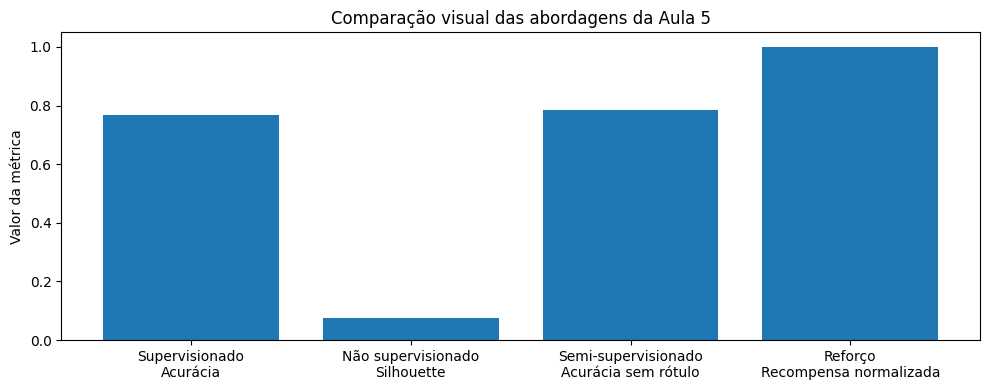

In [91]:
metricas = {
    "Supervisionado\nAcurácia": acc,
    "Não supervisionado\nSilhouette": sil,
    "Semi-supervisionado\nAcurácia sem rótulo": acc_nao_rot,
    "Reforço\nRecompensa normalizada": recompensa_total_heuristica / len(df)
}

plt.figure(figsize=(10,4))
plt.bar(list(metricas.keys()), list(metricas.values()))
plt.title("Comparação visual das abordagens da Aula 5")
plt.ylabel("Valor da métrica")
plt.tight_layout()
plt.show()

### Atenção à comparação das métricas

As métricas dos quatro experimentos **não são diretamente comparáveis**:

- Supervisionado → acurácia;
- Não supervisionado → Silhouette Score;
- Semi-supervisionado → acurácia nos dados originalmente sem rótulo;
- Reforço → recompensa acumulada/normalizada.

Um gráfico único com essas quatro grandezas pode sugerir uma comparação que não existe. Por isso, a análise deve discutir cada resultado dentro do seu próprio contexto.

###***EXTRA***
* Testar Resultados com IA Generativa

> Aqui buscamos apoio da IA Genrativa para checarmos se nossas analises se convergem, utilizamos a IA para validar/respaldar/aprimorar nossas habilidades analiticas e para apresentar um relatorio de alto nível

In [92]:
!pip install -q groq


In [93]:
from groq import Groq
from google.colab import files
import base64

from google.colab import userdata
groq_api_key= userdata.get('api')

client = Groq(api_key=groq_api_key)

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

In [ ]:
arquivo = files.upload()
nome_arquivo = list(arquivo.keys())[0]
print("Arquivo selecionado:", nome_arquivo)
base64_image = encode_image(nome_arquivo)

In [ ]:
prompt= input("Digite aqui sua pergunta===>")
display(prompt)

In [ ]:

response = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"{prompt}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0,

)

print(response.choices[0].message.content)

## 11. Registro final do aluno

Preencha:
- Qual tipo de aprendizado é mais adequado ao projeto atual?
- Qual abordagem poderia complementar a análise?
- O que você entendeu sobre preparação dos dados, treino, validação e métricas?


## Síntese final — leitura crítica dos experimentos

Os quatro experimentos ilustram paradigmas diferentes de aprendizado de máquina, mas seus resultados devem ser interpretados de maneiras diferentes.

**Supervisionado:** a acurácia de 76,67% esconde um desempenho muito desigual entre as classes. O modelo reconhece bem `Normal`, mas apresenta baixo desempenho em `Alerta` e `Falha`. Para uma aplicação de controle, essas classes merecem atenção especial.

**Não supervisionado:** o K-Means produziu três clusters, porém o Silhouette Score de 0,0761 indica baixa separação. Não há evidência suficiente para afirmar que existam três perfis operacionais naturalmente bem definidos.

**Semi-supervisionado:** ao ocultar 60% dos rótulos e aplicar LabelSpreading, foi possível obter 78,47% de acurácia nas amostras que tiveram seus rótulos escondidos. Isso ilustra como dados não rotulados podem contribuir para a classificação quando há uma parcela de exemplos rotulados.

**Reforço:** a comparação entre uma política aleatória e uma política heurística demonstra a relação entre estado, ação e recompensa. Entretanto, a política heurística foi definida manualmente; portanto, esta etapa representa a lógica do aprendizado por reforço, e não um processo de aprendizado de uma política.

### Principal aprendizado

Mais importante do que observar se o código executa é verificar se a **métrica, o experimento e a conclusão são coerentes entre si**.